In [3]:


from pathlib import Path

project_path = Path.cwd().parent
data_folder = project_path / "data"

print("Project folder:", project_path)
print("\nFiles inside data folder:")

for file in data_folder.iterdir():
    print(file.name)



Project folder: c:\Users\Dell\OneDrive\Desktop\Customer-Churn-Prediction

Files inside data folder:
cleaned_churn_data.csv
Telco_customer_churn.csv


In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

project_path = Path.cwd().parent
data_folder = project_path / "data"

file_path = data_folder / "cleaned_churn_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


Dataset loaded successfully!
Number of rows and columns: (7043, 26)

Column names:
['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'CLTV']

First 5 rows:


,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,5372
3,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,5340


In [5]:

print("Available columns:")
for column in df.columns:
    print(column)


Available columns:
City
Zip Code
Lat Long
Latitude
Longitude
Gender
Senior Citizen
Partner
Dependents
Tenure Months
Phone Service
Multiple Lines
Internet Service
Online Security
Online Backup
Device Protection
Tech Support
Streaming TV
Streaming Movies
Contract
Paperless Billing
Payment Method
Monthly Charges
Total Charges
Churn Label
CLTV


In [6]:

possible_targets = ["Churn Label", "Churn", "Churn Value"]

target_col = next(
    (col for col in possible_targets if col in df.columns),
    None
)

if target_col is None:
    raise ValueError(
        "Churn target not found. Check the printed column names."
    )

print("Target column:", target_col)
print(df[target_col].value_counts(dropna=False))


Target column: Churn Label
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:



churn_mapping = {
    "yes": 1,
    "no": 0,
    "churned": 1,
    "retained": 0,
    "true": 1,
    "false": 0,
    "1": 1,
    "0": 0
}

df["Churn_Binary"] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(churn_mapping)
)

df = df.dropna(subset=["Churn_Binary"]).copy()
df["Churn_Binary"] = df["Churn_Binary"].astype(int)

print(df["Churn_Binary"].value_counts())
print("0 = Retained, 1 = Churned")



Churn_Binary
0    5174
1    1869
Name: count, dtype: int64
0 = Retained, 1 = Churned


In [8]:

churn_counts = df["Churn_Binary"].value_counts().reindex(
    [0, 1], fill_value=0
)

retained = int(churn_counts.loc[0])
churned = int(churn_counts.loc[1])
total_customers = retained + churned

churn_percentage = churned / total_customers * 100

print("Total customers:", total_customers)
print("Retained customers:", retained)
print("Churned customers:", churned)
print(f"Churn percentage: {churn_percentage:.2f}%")


Total customers: 7043
Retained customers: 5174
Churned customers: 1869
Churn percentage: 26.54%


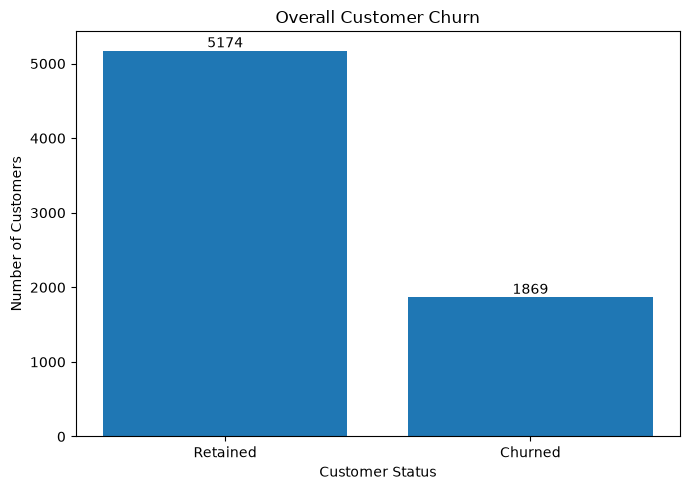

In [9]:

labels = ["Retained", "Churned"]
values = [retained, churned]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values)

plt.title("Overall Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


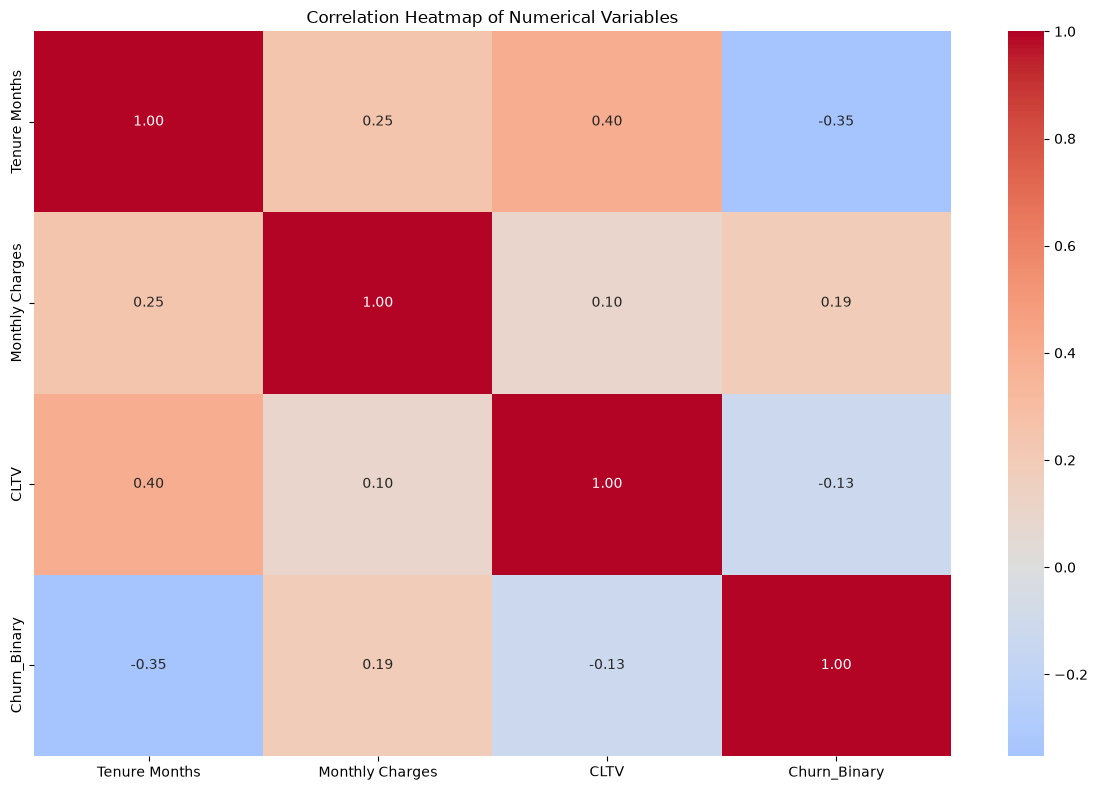

In [10]:

# Select numerical columns
numeric_df = df.select_dtypes(include="number").copy()

# Remove identifiers and geographic columns that aren't
# useful for this numerical relationship analysis.
exclude_columns = [
    "CustomerID", "Count", "Zip Code",
    "Latitude", "Longitude", "Churn Score"
]

numeric_df = numeric_df.drop(
    columns=exclude_columns,
    errors="ignore"
)

# Add our numeric target
numeric_df["Churn_Binary"] = df["Churn_Binary"]

# Calculate correlations
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()


In [12]:

def plot_churn_rate(column, title):
    if column not in df.columns:
        print(f"Column not found: {column}")
        return

    plot_data = df[[column, "Churn_Binary"]].copy()
    plot_data = plot_data.dropna(subset=[column])

    # The mean of a 0/1 column gives the churn rate
    rates = (
        plot_data.groupby(column, observed=True)["Churn_Binary"]
        .mean()
        .mul(100)
        .reset_index(name="Churn Rate (%)")
    )

    rates = rates.sort_values("Churn Rate (%)", ascending=False)

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(
        data=rates,
        x=column,
        y="Churn Rate (%)"
    )

    ax.bar_label(
        ax.containers[0],
        fmt="%.1f%%",
        padding=3
    )

    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, min(110, max(10, rates["Churn Rate (%)"].max() * 1.2)))
    plt.tight_layout()
    plt.show()


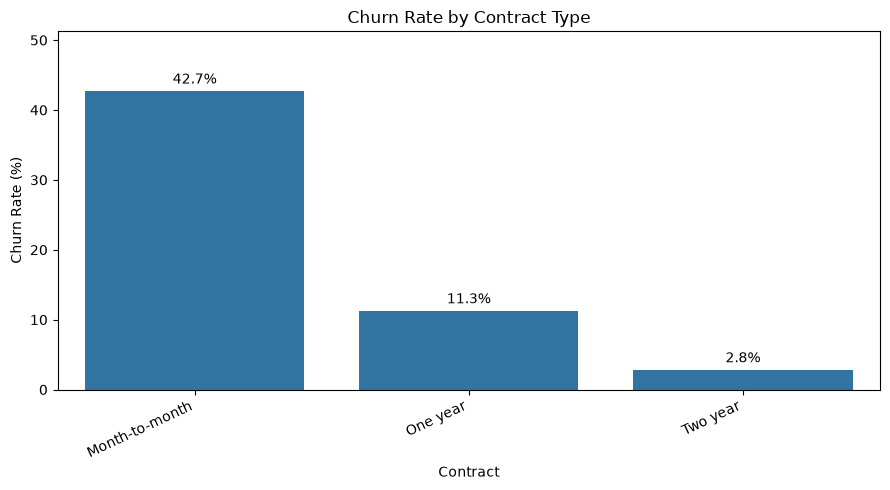

In [13]:

plot_churn_rate(
    "Contract",
    "Churn Rate by Contract Type"
)


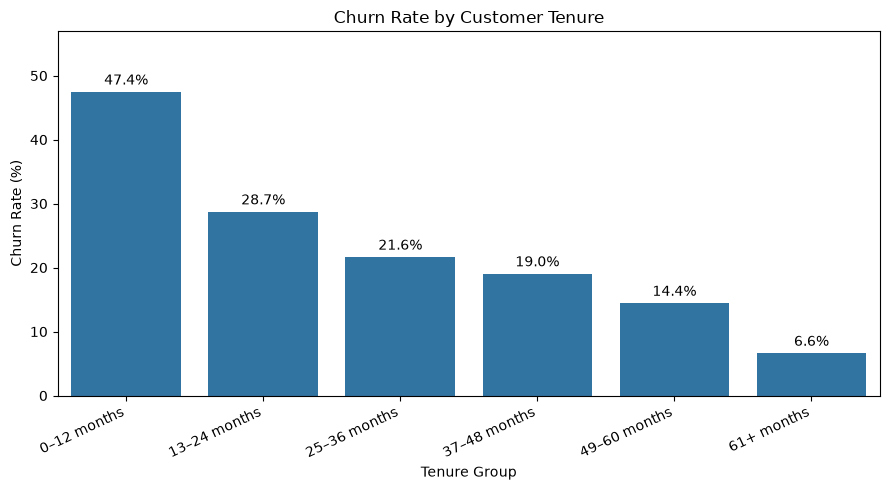

In [14]:

if "Tenure Months" in df.columns:
    df["Tenure Group"] = pd.cut(
        pd.to_numeric(df["Tenure Months"], errors="coerce"),
        bins=[-1, 12, 24, 36, 48, 60, float("inf")],
        labels=[
            "0–12 months",
            "13–24 months",
            "25–36 months",
            "37–48 months",
            "49–60 months",
            "61+ months"
        ]
    )

    plot_churn_rate(
        "Tenure Group",
        "Churn Rate by Customer Tenure"
    )
else:
    print("Tenure Months column not found.")


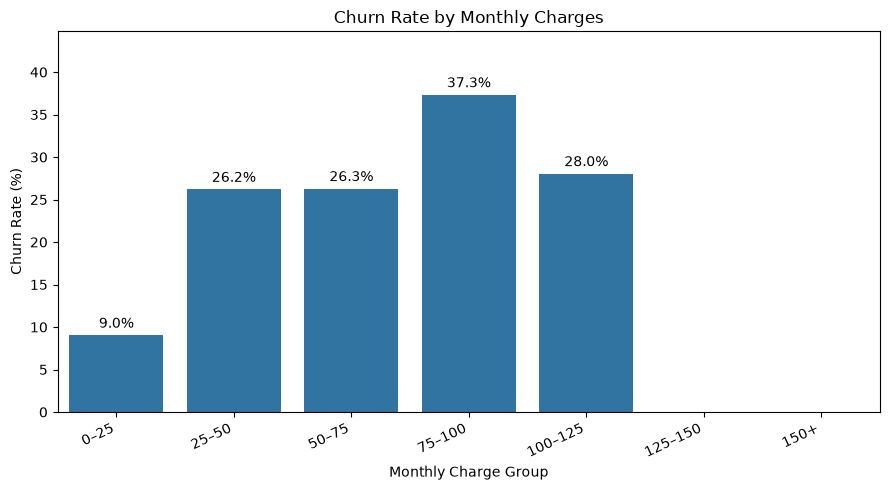

In [15]:

if "Monthly Charges" in df.columns:
    df["Monthly Charge Group"] = pd.cut(
        pd.to_numeric(df["Monthly Charges"], errors="coerce"),
        bins=[0, 25, 50, 75, 100, 125, 150, float("inf")],
        labels=[
            "0–25", "25–50", "50–75", "75–100",
            "100–125", "125–150", "150+"
        ],
        include_lowest=True
    )

    plot_churn_rate(
        "Monthly Charge Group",
        "Churn Rate by Monthly Charges"
    )
else:
    print("Monthly Charges column not found.")


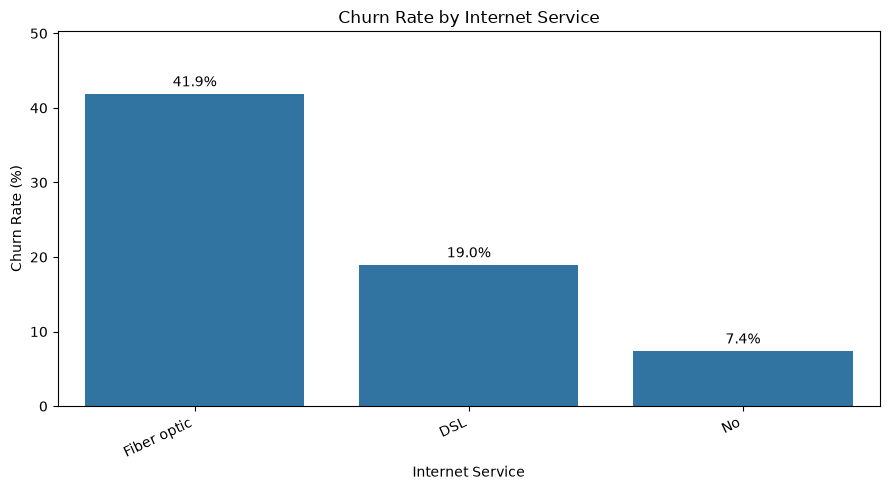

In [16]:

plot_churn_rate(
    "Internet Service",
    "Churn Rate by Internet Service"
)


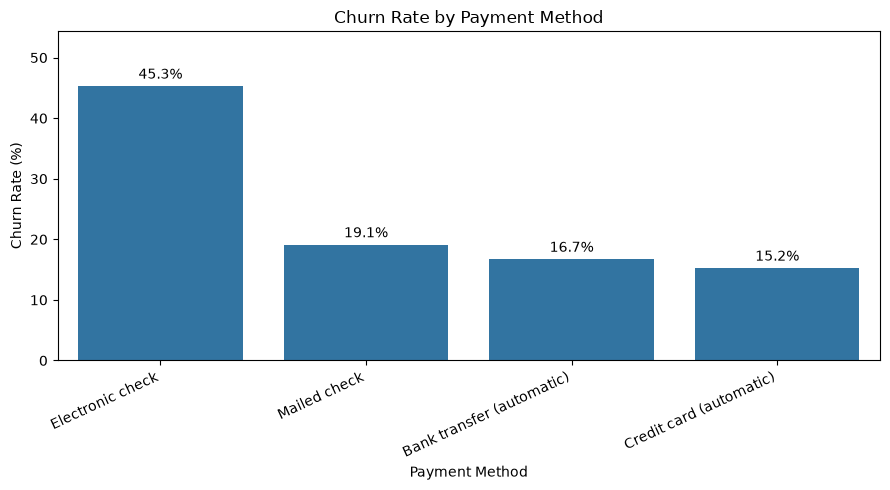

In [17]:

plot_churn_rate(
    "Payment Method",
    "Churn Rate by Payment Method"
)



# Final Observations

1. The overall customer churn rate is 26.54%.

2. The contract category with the highest churn rate is month to month.

3. Customers in the 0-12 tenure group have the highest churn rate.

4. Customers in the 75-100 monthly-charge range have the highest churn rate.

5. The internet service category with the highest churn rate is fiber optic .

6. Customers using electronic check as their payment method have the highest churn rate.

7. The correlation heatmap shows a _moderate negative  relationship between tenure and churn.

8. The correlation heatmap shows a _weak positive relationship between monthly charges and churn.

9. The overall churn chart shows that 1869 customers churned out of 7043 customers.

10. These findings identify customer groups with different churn rates
    and may help guide further investigation into customer retention.
